### Khám phá dữ liệu

#### Đọc dữ liệu

In [1]:
import pandas as pd
df = pd.read_csv("reviews.csv")
print(f'Số dòng: {len(df):,}')
print(f'Số cột: {len(df.columns)}')
print()
print('Tên các cột:')
print(df.columns.tolist())

Số dòng: 568,454
Số cột: 10

Tên các cột:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [2]:
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


#### Xem thông tin 2 cột cần dùng

In [3]:
df = df[['Text', 'Score']].copy()

print('Thống kê 2 cột cần dùng:')
print(df.info())
print()
print('Số giá trị null:')
print(df.isnull().sum())

Thống kê 2 cột cần dùng:
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   Text    568454 non-null  str  
 1   Score   568454 non-null  int64
dtypes: int64(1), str(1)
memory usage: 8.7 MB
None

Số giá trị null:
Text     0
Score    0
dtype: int64


#### Thống kê mô tả cột Score

In [4]:
df["Score"].describe()

count    568454.000000
mean          4.183199
std           1.310436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Score, dtype: float64

#### Kiểm tra giá trị trùng lặp

In [5]:
# Lưu lại dữ liệu trước khi xử lý
df_before = df.copy()

# Số lượng bản ghi trước xử lý
before_rows = len(df_before)

# Kiểm tra số lượng bản ghi trùng lặp
duplicate_before = df_before.duplicated().sum()

print(f"Số lượng bản ghi trước xử lý : {before_rows:,}")
print(f"Số lượng bản ghi trùng lặp   : {duplicate_before:,}")

# Hiển thị một vài bản ghi trùng lặp
duplicates = df_before[df_before.duplicated()]
duplicates.head()

Số lượng bản ghi trước xử lý : 568,454
Số lượng bản ghi trùng lặp   : 174,779


,Text,Score
29,I don't know if it's the cactus or the tequila...,5
574,"I'm addicted to salty and tangy flavors, so wh...",5
603,"I'm addicted to salty and tangy flavors, so wh...",5
1973,The pork chops from Omaha Steaks were very tas...,3
2309,Too much of the white pith on this orange peel...,2


### Tiền xử lý dữ liệu

#### Loại bỏ review trùng lặp

In [6]:
df = df_before.drop_duplicates()

print(f"Số lượng bản ghi sau khi xóa: {len(df):,}")

duplicate_after = df.duplicated().sum()

print(f"Số bản ghi trùng lặp còn lại: {duplicate_after}")

Số lượng bản ghi sau khi xóa: 393,675
Số bản ghi trùng lặp còn lại: 0


In [7]:
# ==========================================================
# Bảng tổng hợp kết quả
# ==========================================================

after_rows = len(df)
removed_rows = before_rows - after_rows

summary_duplicate = pd.DataFrame({
    'Chỉ tiêu': [
        'Số bản ghi trước xử lý',
        'Số bản ghi trùng lặp',
        'Số bản ghi sau xử lý',
        'Số bản ghi đã loại bỏ',
        'Số bản ghi trùng lặp còn lại'
    ],
    'Giá trị': [
        before_rows,
        duplicate_before,
        after_rows,
        removed_rows,
        duplicate_after
    ]
})

summary_duplicate

,Chỉ tiêu,Giá trị
0,Số bản ghi trước xử lý,568454
1,Số bản ghi trùng lặp,174779
2,Số bản ghi sau xử lý,393675
3,Số bản ghi đã loại bỏ,174779
4,Số bản ghi trùng lặp còn lại,0


#### Xử lý cột text

In [8]:
!pip install nltk

##### Build hàm clean_text()

In [9]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Pipeline làm sạch văn bản gồm 5 bước:
    1. Xóa HTML tags (vd: <br/>, <p>, &amp;)
    2. Xóa ký tự đặc biệt, chỉ giữ chữ cái
    3. Chuyển về chữ thường (lowercase)
    4. Loại stop words (the, is, at, ...)
    5. Ghép lại thành chuỗi
    """
    # Bước 1: Xóa HTML tags
    text = re.sub(r'<.*?>', ' ', str(text))

    # Bước 2: Xóa ký tự đặc biệt
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Bước 3 : Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    # Bước 4: Lowercase
    text = text.lower()
    
    # Bước 5 : Tokenize
    tokens = text.split()

    # Bước 6: Loại stop words
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    
    # Bước 7: Ghép lại
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\NHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##### Test case

In [10]:
examples = [
    "<br/>This is a GREAT product!! I love it :)",
    "Terrible quality... waste of money!!! 100% NOT recommended.",
    "It's okay, nothing special about this product."
]

print('=== Kiểm tra hàm clean_text() ===')
for i, ex in enumerate(examples, 1):
    print(f'\nVí dụ {i}:')
    print(f'  Trước: {ex}')
    print(f'  Sau:   {clean_text(ex)}')

=== Kiểm tra hàm clean_text() ===

Ví dụ 1:
  Trước: <br/>This is a GREAT product!! I love it :)
  Sau:   great product love

Ví dụ 2:
  Trước: Terrible quality... waste of money!!! 100% NOT recommended.
  Sau:   terrible quality waste money recommended

Ví dụ 3:
  Trước: It's okay, nothing special about this product.
  Sau:   okay nothing special product


In [11]:
# Áp dụng lên dataset

print('Đang làm sạch văn bản... (vui lòng chờ)')

df['clean_text'] = df['Text'].apply(clean_text)

# Xóa các dòng sau khi làm sạch bị rỗng

df = df[df['clean_text'].str.strip() != '']

print(f'Hoàn thành! Số dòng còn lại: {len(df):,}')

# Kiểm tra kết quả: xem 5 cặp trước/sau

print('=== 5 ví dụ trước/sau làm sạch ===')

for i, row in df.head(5).iterrows():
    print(f'\nDòng {i + 1}:')
    print(f'  Trước: {str(row["Text"])[:100]}...')
    print(f'  Sau:   {row["clean_text"][:100]}...')

Đang làm sạch văn bản... (vui lòng chờ)
Hoàn thành! Số dòng còn lại: 393,672
=== 5 ví dụ trước/sau làm sạch ===

Dòng 1:
  Trước: I have bought several of the Vitality canned dog food products and have found them all to be of good...
  Sau:   bought several vitality canned dog food products found good quality product looks like stew processe...

Dòng 2:
  Trước: Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. No...
  Sau:   product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor...

Dòng 3:
  Trước: This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin wi...
  Sau:   confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberal...

Dòng 4:
  Trước: If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in...
  Sau:   looking secret ingredient robitussin believe found g

#### Xử lý cột Score

##### Build hàm assign_label() gán nhãn 3 lớp cảm xúc

In [12]:
def assign_label(rating):
    """
    Chuyển rating số thành nhãn cảm xúc:
    - 4, 5 sao  → Positive
    - 3 sao     → Neutral
    - 1, 2 sao  → Negative
    """
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

In [13]:
df['label'] = df['Score'].apply(assign_label)

print('Phân phối nhãn:')
print(df['label'].value_counts())
print()
print('Tỉ lệ (%):')
print((df['label'].value_counts(normalize=True) * 100).round(1))

Phân phối nhãn:
label
Positive    306816
Negative     57084
Neutral      29772
Name: count, dtype: int64

Tỉ lệ (%):
label
Positive    77.9
Negative    14.5
Neutral      7.6
Name: proportion, dtype: float64


##### Biểu đồ phân phối nhãn

In [14]:
!pip install matplotlib

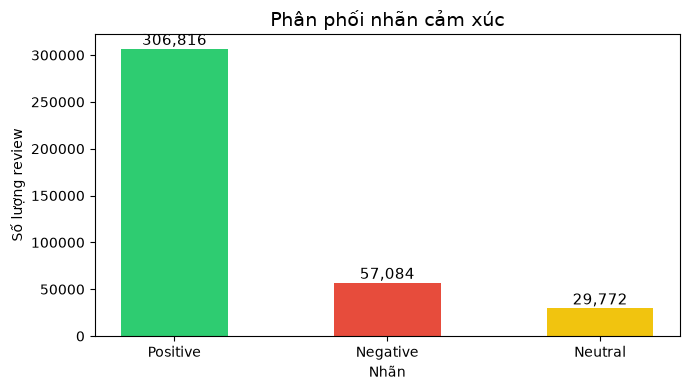

Đã lưu: outputs/label_distribution.png


In [15]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()
colors = ['#2ECC71', '#E74C3C', '#F1C40F']

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values, color=colors, width=0.5)
plt.title('Phân phối nhãn cảm xúc', fontsize=14)
plt.xlabel('Nhãn')
plt.ylabel('Số lượng review')

# Hiển thị số lượng trên đầu mỗi cột
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/label_distribution.png', dpi=150)
plt.show()
print('Đã lưu: outputs/label_distribution.png')

#### Nhận xét

In [16]:
# Nhận xét về phân phối nhãn
total = len(df)
for label in ['Positive', 'Neutral', 'Negative']:
    count = (df['label'] == label).sum()
    pct = count / total * 100
    print(f'{label:10s}: {count:>6,} reviews ({pct:.1f}%)')

print()
print('=> Nhận xét: Dữ liệu bị mất cân bằng lớp (imbalanced).')
print('   Nhóm Positive chiếm đa số, Neutral rất ít.')
print('   Vì vậy cần dùng Macro F1 thay vì Accuracy để đánh giá mô hình.')

Positive  : 306,816 reviews (77.9%)
Neutral   : 29,772 reviews (7.6%)
Negative  : 57,084 reviews (14.5%)

=> Nhận xét: Dữ liệu bị mất cân bằng lớp (imbalanced).
   Nhóm Positive chiếm đa số, Neutral rất ít.
   Vì vậy cần dùng Macro F1 thay vì Accuracy để đánh giá mô hình.


### Lưu kết quả

In [17]:
import os

# Tạo thư mục nếu chưa có
os.makedirs('data', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Lưu file với 3 cột cần thiết cho các bước tiếp theo
df_output = df[['Text', 'clean_text', 'Score', 'label']]
df_output.to_csv('data/reviews_labeled.csv', index=False)

print(f'Đã lưu: data/processed/reviews_labeled.csv')
print(f'Số dòng: {len(df_output):,}')
print(f'Số cột: {len(df_output.columns)}')
print()
print('Xem trước file output:')
df_output.head(3)

Đã lưu: data/processed/reviews_labeled.csv
Số dòng: 393,672
Số cột: 4

Xem trước file output:


,Text,clean_text,Score,label
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanuts p...,1,Negative
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...,4,Positive
